### Use About Data:Random Forest to prepare a model on fraud data. Treating those who have taxable income <= 30000 as "Risky" and others are "Good".


### import the Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load the datasets

In [2]:
df = pd.read_csv('Fraud_check.csv')

In [3]:
df.head()

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
0,NO,Single,68833,50047,10,YES
1,YES,Divorced,33700,134075,18,YES
2,NO,Married,36925,160205,30,YES
3,YES,Single,50190,193264,15,YES
4,NO,Married,81002,27533,28,NO


In [4]:
df.describe()

,Taxable.Income,City.Population,Work.Experience
count,600.000000,600.000000,600.000000
mean,55208.375000,108747.368333,15.558333
std,26204.827597,49850.075134,8.842147
min,10003.000000,25779.000000,0.000000
25%,32871.500000,66966.750000,8.000000
50%,55074.500000,106493.500000,15.000000
75%,78611.750000,150114.250000,24.000000
max,99619.000000,199778.000000,30.000000


#### Data Preprocessing

#### Handling missing values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Undergrad        600 non-null    object
 1   Marital.Status   600 non-null    object
 2   Taxable.Income   600 non-null    int64 
 3   City.Population  600 non-null    int64 
 4   Work.Experience  600 non-null    int64 
 5   Urban            600 non-null    object
dtypes: int64(3), object(3)
memory usage: 28.3+ KB


In [6]:
df.isnull().sum()

Undergrad          0
Marital.Status     0
Taxable.Income     0
City.Population    0
Work.Experience    0
Urban              0
dtype: int64

#### Duplicates

In [7]:
df.duplicated().sum()

0

In [8]:
df[df.duplicated()]

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban


##### make a target column for random forest classifier

In [9]:
df['target'] = df['Taxable.Income'].apply(lambda x: 0 if x < 30000 else 1)

In [10]:
df.head()

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban,target
0,NO,Single,68833,50047,10,YES,1
1,YES,Divorced,33700,134075,18,YES,1
2,NO,Married,36925,160205,30,YES,1
3,YES,Single,50190,193264,15,YES,1
4,NO,Married,81002,27533,28,NO,1


In [11]:
df['target'].value_counts()

target
1    476
0    124
Name: count, dtype: int64

#### Drop the target columns and Taxable.Income

In [12]:
X = df.drop(['Taxable.Income', 'target'], axis=1)
y = df['target']

#### outliers

In [13]:
num_columns = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

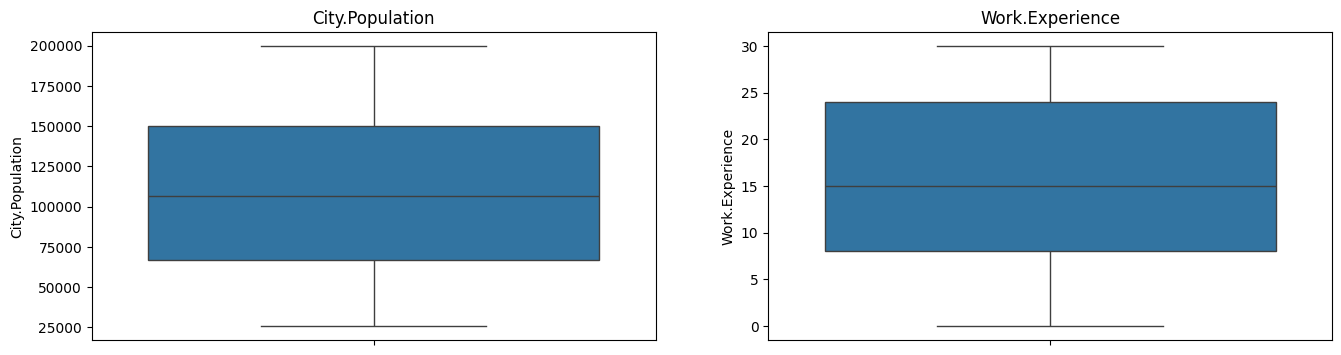

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=len(num_columns), figsize=(16, 4))

for i, col in enumerate(num_columns):
    if col in X.columns:  # Ensure the column exists
        sns.boxplot(data=X, y=col, ax=axes[i])
        axes[i].set_title(col)

In [15]:
X

,Undergrad,Marital.Status,City.Population,Work.Experience,Urban
0,NO,Single,50047,10,YES
1,YES,Divorced,134075,18,YES
2,NO,Married,160205,30,YES
3,YES,Single,193264,15,YES
4,NO,Married,27533,28,NO
...,...,...,...,...,...
595,YES,Divorced,39492,7,YES
596,YES,Divorced,55369,2,YES
597,NO,Divorced,154058,0,YES
598,YES,Married,180083,17,NO


### One Hot Encoding

In [16]:
X = pd.get_dummies(X)

In [17]:
X

,City.Population,Work.Experience,Undergrad_NO,Undergrad_YES,Marital.Status_Divorced,Marital.Status_Married,Marital.Status_Single,Urban_NO,Urban_YES
0,50047,10,True,False,False,False,True,False,True
1,134075,18,False,True,True,False,False,False,True
2,160205,30,True,False,False,True,False,False,True
3,193264,15,False,True,False,False,True,False,True
4,27533,28,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...
595,39492,7,False,True,True,False,False,False,True
596,55369,2,False,True,True,False,False,False,True
597,154058,0,True,False,True,False,False,False,True
598,180083,17,False,True,False,True,False,True,False


# Scaling

In [18]:
num_columns = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_columns] = scaler.fit_transform(df[num_columns])

# Train Test Split

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Model

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
y_pred = rf_clf.predict(X_test)

# metrics

In [24]:
from sklearn.metrics import precision_score,recall_score,f1_score
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

In [25]:
print('precision : ',precision )
print('recall : ', recall)
print('f1_score : ',f1 )

precision :  0.7721518987341772
recall :  0.8531468531468531
f1_score :  0.8106312292358804


In [26]:
#https://www.google.com/search?q=random+forest+classifier+affected+by+multicollinearity&rlz=1C1ONGR_enIN1054IN1054&oq=random+forest+classifier+affect+&gs_lcrp=EgZjaHJvbWUqBwgCECEYnwUyCQgAEEUYORifBTIHCAEQIRigATIHCAIQIRifBTIHCAMQIRifBdIBCTEzMDAyajBqN6gCCLACAQ&sourceid=chrome&ie=UTF-8